dependencies

In [2]:
!pip install kaggle xgboost shap imbalanced-learn --quiet
print("Setup done.")

Setup done.


Download the dataset

In [3]:
import os

# Set the Kaggle API token directly from the provided token
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_9bbb36b64c14da62e1aa712d65627410'

# Create the .kaggle directory and set permissions
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"omkarparelkar","key":"KGAT_9bbb36b64c14da62e1aa712d65627410"}')
!chmod 600 /root/.kaggle/kaggle.json

# Official public SGCC dataset — legal, licensed for research/ML use
!kaggle datasets download -d bensalem14/sgcc-dataset
!unzip -o sgcc-dataset.zip -d sgcc_data
!ls sgcc_data

Dataset URL: https://www.kaggle.com/datasets/bensalem14/sgcc-dataset
License(s): DbCL-1.0
100% 51.2M/51.2M [00:00<00:00, 91.4MB/s]

Archive:  sgcc-dataset.zip
  inflating: sgcc_data/data set.csv  
  inflating: sgcc_data/datasetsmall.csv  
'data set.csv'	 datasetsmall.csv


Load and inspect the data

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('sgcc_data/data set.csv')  # adjust filename if different
print("Shape:", df.shape)
display(df.head())

Shape: (42372, 1036)


,1/1/2014,1/2/2014,1/3/2014,1/4/2014,1/5/2014,1/6/2014,1/7/2014,1/8/2014,1/9/2014,1/10/2014,...,10/24/2016,10/25/2016,10/26/2016,10/27/2016,10/28/2016,10/29/2016,10/30/2016,10/31/2016,CONS_NO,FLAG
0,0.0,0.0,0.01,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.02,0.06,0.58,0.89,0.35,0.38,0.70,0.25,0387DD8A07E07FDA6271170F86AD9151,1
1,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,17.13,14.32,16.37,26.33,19.06,17.38,13.94,14.14,01D6177B5D4FFE0CABA9EF17DAFC2B84,1
2,0.0,0.0,0.00,0.0,0.0,4.98,9.87,11.29,13.44,11.34,...,NaN,1.43,2.22,2.41,3.48,2.89,1.88,1.16,4B75AC4F2D8434CFF62DB64D0BB43103,1
3,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,20.98,18.47,15.50,14.80,19.28,16.10,17.51,16.67,B32AC8CC6D5D805AC053557AB05F5343,1
4,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.61,1.33,0.55,1.62,1.53,2.10,1.16,2.13,EDFC78B07BA2908B3395C4EB2304665E,1


In [8]:
# Separate ID, dates, and label
label_col = df.columns[-1]
id_col = df.columns[-2] # Corrected: 'CONS_NO' is the second to last column
date_cols = df.columns[0:-2] # Corrected: All columns before 'CONS_NO' and 'FLAG'

y = df[label_col]
X_raw = df[date_cols]

# Interpolate missing values per row (per customer), then fill remaining with 0
X_raw = X_raw.interpolate(method='linear', axis=1, limit_direction='both')
X_raw = X_raw.fillna(0)

# Cap extreme outliers using 3-sigma rule (standard for this dataset)
def cap_outliers(row):
    mean, std = row.mean(), row.std()
    upper = mean + 3 * std
    return row.clip(upper=upper)

X_raw = X_raw.apply(cap_outliers, axis=1)

print("Cleaned shape:", X_raw.shape)
print("Theft ratio: {:.2f}%".format(y.mean() * 100))

Cleaned shape: (42372, 1034)
Theft ratio: 8.53%


In [9]:
features = pd.DataFrame(index=X_raw.index)

features['mean_consumption'] = X_raw.mean(axis=1)
features['std_consumption'] = X_raw.std(axis=1)
features['min_consumption'] = X_raw.min(axis=1)
features['max_consumption'] = X_raw.max(axis=1)
features['median_consumption'] = X_raw.median(axis=1)
features['skewness'] = X_raw.skew(axis=1)
features['kurtosis'] = X_raw.kurt(axis=1)
features['zero_days_pct'] = (X_raw == 0).sum(axis=1) / X_raw.shape[1] * 100

# Rolling trend: split into first half vs second half of time window, compare
mid = X_raw.shape[1] // 2
features['first_half_mean'] = X_raw.iloc[:, :mid].mean(axis=1)
features['second_half_mean'] = X_raw.iloc[:, mid:].mean(axis=1)
features['consumption_drop_pct'] = (
    (features['first_half_mean'] - features['second_half_mean'])
    / (features['first_half_mean'] + 1e-6) * 100
)

# Weekly variance (captures irregular tampering patterns)
weekly = X_raw.T.groupby(np.arange(X_raw.shape[1]) // 7).mean().T
features['weekly_variance'] = weekly.var(axis=1)

features = features.fillna(0)
print("Feature set shape:", features.shape)
display(features.head())

Feature set shape: (42372, 12)


,mean_consumption,std_consumption,min_consumption,max_consumption,median_consumption,skewness,kurtosis,zero_days_pct,first_half_mean,second_half_mean,consumption_drop_pct,weekly_variance
0,0.818243,2.559935,0.0,10.257829,0.000000,3.131287,8.199514,83.655706,1.602598,0.033888,9.788538e+01,6.240402
1,4.169827,6.245569,0.0,24.903396,1.281101,1.896169,2.437106,4.835590,0.560783,7.778871,-1.287141e+03,38.330909
2,8.448021,7.975831,0.0,37.955211,6.590937,1.733198,3.568562,3.288201,8.567448,8.328594,2.787923e+00,50.774129
3,3.611941,7.450806,0.0,27.959906,0.000000,2.051422,3.226987,77.369439,0.000000,7.223881,-7.223881e+08,54.989752
4,87.728205,43.127560,0.0,226.261421,88.598013,-0.138536,0.041000,3.675048,105.404647,70.051763,3.354016e+01,1739.720067


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, stratify=y, random_state=42
)

print("Train theft ratio: {:.2f}%".format(y_train.mean() * 100))
print("Test theft ratio: {:.2f}%".format(y_test.mean() * 100))

Train theft ratio: 8.53%
Test theft ratio: 8.53%


In [11]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

xgb_model.fit(X_train, y_train)

preds = xgb_model.predict(X_test)
probs = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost Performance ===")
print(classification_report(y_test, preds))
print("AUC-ROC:", roc_auc_score(y_test, probs))
print("F1 Score:", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

=== XGBoost Performance ===
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      7752
           1       0.21      0.53      0.30       723

    accuracy                           0.79      8475
   macro avg       0.58      0.67      0.59      8475
weighted avg       0.89      0.79      0.83      8475

AUC-ROC: 0.7491565108972904
F1 Score: 0.2991819244253993
Confusion Matrix:
 [[6292 1460]
 [ 339  384]]


In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

# Scale the raw consumption data (X_raw)
scaler = StandardScaler()
X_raw_scaled = scaler.fit_transform(X_raw)

# Split scaled X_raw into train/test using the same indices as the feature-engineered data
X_raw_train = X_raw_scaled[X_train.index]
X_raw_test = X_raw_scaled[X_test.index]

# Reshape input for LSTM: (samples, timesteps, features)
# Here, each day's consumption is a timestep, and there's 1 feature per timestep
X_raw_train_reshaped = X_raw_train.reshape(X_raw_train.shape[0], X_raw_train.shape[1], 1)
X_raw_test_reshaped = X_raw_test.reshape(X_raw_test.shape[0], X_raw_test.shape[1], 1)

# Define the LSTM model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_raw_train_reshaped.shape[1], 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# Train the model
print("\n=== Training LSTM Model ===")
history = lstm_model.fit(
    X_raw_train_reshaped, y_train,
    epochs=10, # Reduced epochs for quicker execution. Can be increased for better performance.
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model
lstm_probs = lstm_model.predict(X_raw_test_reshaped).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)

print("\n=== LSTM Performance ===")
print(classification_report(y_test, lstm_preds))
print("AUC-ROC:", roc_auc_score(y_test, lstm_probs))
print("F1 Score:", f1_score(y_test, lstm_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, lstm_preds))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



=== Training LSTM Model ===
Epoch 1/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - AUC: 0.5895 - loss: 0.2952 - val_AUC: 0.6586 - val_loss: 0.2867
Epoch 2/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - AUC: 0.6361 - loss: 0.2762 - val_AUC: 0.6574 - val_loss: 0.2819
Epoch 3/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - AUC: 0.6500 - loss: 0.2747 - val_AUC: 0.6597 - val_loss: 0.2835
Epoch 4/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - AUC: 0.6490 - loss: 0.2739 - val_AUC: 0.6577 - val_loss: 0.2826
Epoch 5/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - AUC: 0.6401 - loss: 0.2748 - val_AUC: 0.6590 - val_loss: 0.2820
Epoch 6/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - AUC: 0.6481 - loss: 0.2740 - val_AUC: 0.6556 - val_loss: 0.2830
Epoch 7/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - AUC: 0.6510 - loss: 0.2734 - val_AUC: 0.6592 - val_loss: 0.2837
Epoch 8/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - AUC: 0.6499 - loss: 0.2735 - val_AUC: 0.6594 - val_loss: 0.2842
Epoch 9/10


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

# Scale sequences 0-1 for LSTM stability
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

# Reshape for LSTM: (samples, timesteps, features=1)
X_seq = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

X_seq_train, X_seq_test, y_seq_train, y_seq_test = train_test_split(
    X_seq, y, test_size=0.2, stratify=y, random_state=42
)

lstm_model = models.Sequential([
    layers.Input(shape=(X_seq.shape[1], 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

class_weight = {0: 1.0, 1: scale_pos_weight}

history = lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weight,
    verbose=1
)

lstm_probs = lstm_model.predict(X_seq_test).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)

print("=== LSTM Performance ===")
print(classification_report(y_seq_test, lstm_preds))
print("AUC-ROC:", roc_auc_score(y_seq_test, lstm_probs))

Epoch 1/15
477/477 ━━━━━━━━━━━━━━━━━━━━ 39s 75ms/step - AUC: 0.5090 - loss: 1.2612 - val_AUC: 0.5401 - val_loss: 0.6641
Epoch 2/15
477/477 ━━━━━━━━━━━━━━━━━━━━ 48s 89ms/step - AUC: 0.5056 - loss: 1.2588 - val_AUC: 0.5077 - val_loss: 0.6935
Epoch 3/15
477/477 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - AUC: 0.4989 - loss: 1.2712 - val_AUC: 0.5058 - val_loss: 0.7054
Epoch 4/15
477/477 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - AUC: 0.4999 - loss: 1.2635 - val_AUC: 0.5000 - val_loss: 0.6987
Epoch 5/15
477/477 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - AUC: 0.4912 - loss: 1.2637 - val_AUC: 0.5016 - val_loss: 0.6536
Epoch 6/15
477/477 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - AUC: 0.4846 - loss: 1.2639 - val_AUC: 0.5000 - val_loss: 0.6995
Epoch 7/15
477/477 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - AUC: 0.4933 - loss: 1.2636 - val_AUC: 0.5016 - val_loss: 0.6880
Epoch 8/15
477/477 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - AUC: 0.4930 - loss: 1.2629 - val_AUC: 0.5000 - val_loss: 0.6843
Epoch 9/15
477/477 ━━━━━━━━━━━━━━━━━━━━ 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Compare both models Comparative Analysis

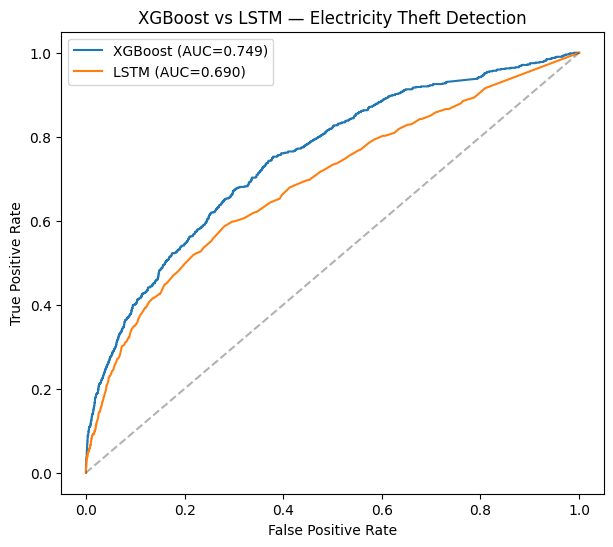

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, probs)
fpr_lstm, tpr_lstm, _ = roc_curve(y_seq_test, lstm_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, probs):.3f})")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={roc_auc_score(y_seq_test, lstm_probs):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost vs LSTM — Electricity Theft Detection")
plt.legend()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

SHAP explainability - Key Differntiator

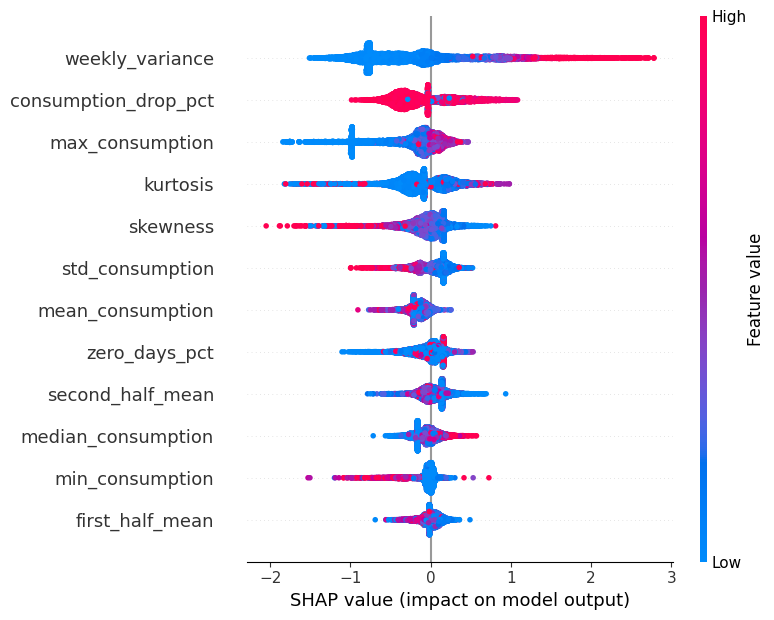

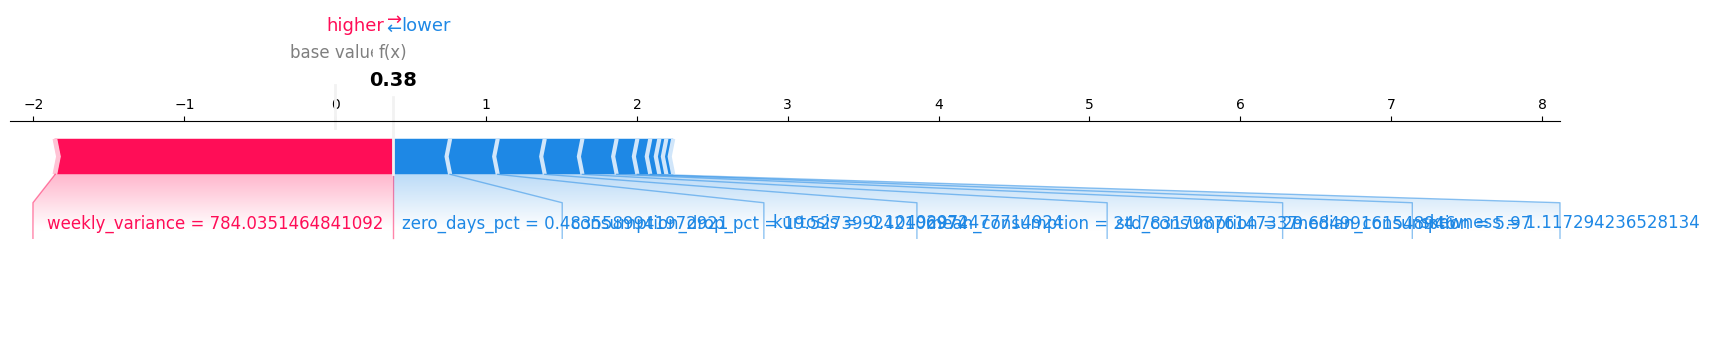

In [15]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Global feature importance — which factors matter most overall
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Individual explanation — why ONE specific customer was flagged
sample_idx = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.savefig('shap_individual_example.png', dpi=150, bbox_inches='tight')
plt.show()

Save model, metrics, and India-context notes


In [16]:
import json

xgb_model.save_model('vidyutrakshak_xgb_model.json')
lstm_model.save('vidyutrakshak_lstm_model.h5')

metrics_summary = {
    "dataset": "SGCC (State Grid Corporation of China) — public benchmark, used as proxy due to no public Indian DISCOM theft-labeled dataset existing",
    "xgboost": {
        "auc": float(roc_auc_score(y_test, probs)),
        "f1": float(f1_score(y_test, preds)),
    },
    "lstm": {
        "auc": float(roc_auc_score(y_seq_test, lstm_probs)),
    },
    "india_deployment_note": (
        "Model architecture and feature pipeline are designed to be format-agnostic. "
        "For Indian deployment, this same pipeline would ingest data from DISCOM smart "
        "meters under India's Smart Metering National Programme, and be fine-tuned "
        "(transfer learning) on real Indian consumption + confirmed-theft records once "
        "available via state utility partnerships (e.g. MSEDCL, BSES, Tata Power)."
    )
}

with open('metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print(json.dumps(metrics_summary, indent=2))

# Download everything to your computer
from google.colab import files
files.download('vidyutrakshak_xgb_model.json')
files.download('metrics.json')
files.download('model_comparison.png')
files.download('shap_summary.png')
files.download('shap_individual_example.png')

{
  "dataset": "SGCC (State Grid Corporation of China) \u2014 public benchmark, used as proxy due to no public Indian DISCOM theft-labeled dataset existing",
  "xgboost": {
    "auc": 0.7491565108972904,
    "f1": 0.2991819244253993
  },
  "lstm": {
    "auc": 0.6900672222008115
  },
  "india_deployment_note": "Model architecture and feature pipeline are designed to be format-agnostic. For Indian deployment, this same pipeline would ingest data from DISCOM smart meters under India's Smart Metering National Programme, and be fine-tuned (transfer learning) on real Indian consumption + confirmed-theft records once available via state utility partnerships (e.g. MSEDCL, BSES, Tata Power)."
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 2000x300 with 0 Axes>

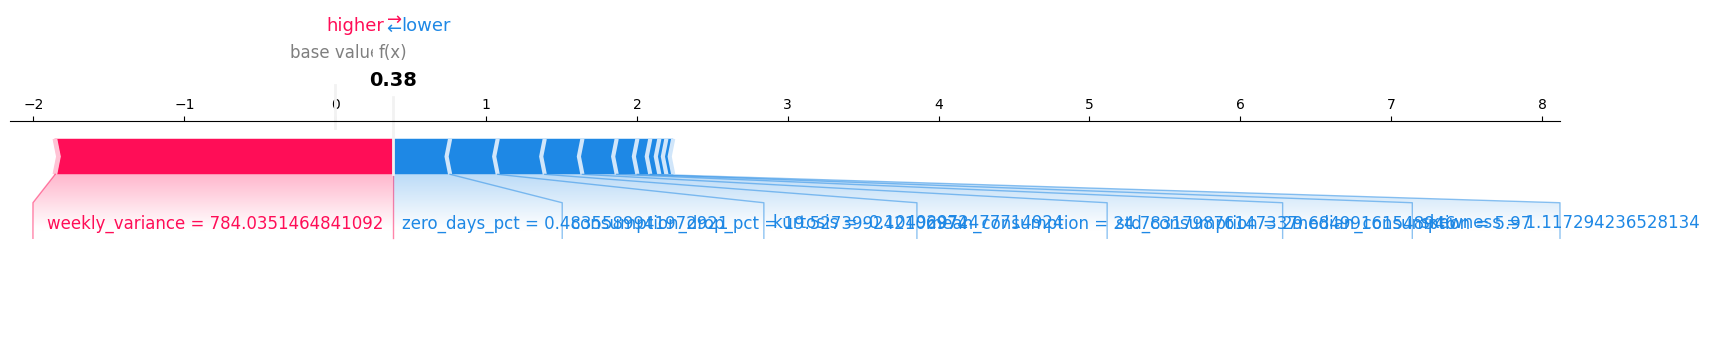

In [17]:
plt.figure(figsize=(20, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.savefig('shap_individual_example.png', dpi=200, bbox_inches='tight')
plt.show()